In [1]:
import math

from qiskit.quantum_info import Statevector, Operator, partial_trace, SparsePauliOp
from qiskit import qpy, QuantumCircuit
import numpy as np
from qiskit.synthesis import TwoQubitWeylDecomposition
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Session, Batch

from QuditsOnQubits import create_ame_circuit, generate_b_ame
from sympy.functions.combinatorial.numbers import legendre_symbol
from IPython.display import display, Math
from itertools import product
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import StatePreparation
from igraph import Graph, plot
import matplotlib.pyplot as plt
import matplotlib.ticker as tck

C:\Users\szymo\anaconda3\envs\qudityD3_laptop\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

In [60]:
with open('Xgate3.qpy', 'rb') as fd:
    Xgate3 = qpy.load(fd)[0]

with open('Zgate3.qpy', 'rb') as fd:
    Zgate3 = qpy.load(fd)[0]

with open('Xgate4.qpy', 'rb') as fd:
    Xgate4 = qpy.load(fd)[0]

with open('Zgate4.qpy', 'rb') as fd:
    Zgate4 = qpy.load(fd)[0]

with open('Xgate3dag.qpy', 'rb') as fd:
    Xgate3dag = qpy.load(fd)[0]

with open('Zgate3dag.qpy', 'rb') as fd:
    Zgate3dag = qpy.load(fd)[0]

with open('Xgate4dag.qpy', 'rb') as fd:
    Xgate4dag = qpy.load(fd)[0]

with open('Zgate4dag.qpy', 'rb') as fd:
    Zgate4dag = qpy.load(fd)[0]

with open('FDAGgate3.qpy', 'rb') as fd:
    FDAGgate3 = qpy.load(fd)[0]

with open('FDAGgate4.qpy', 'rb') as fd:
    FDAGgate4 = qpy.load(fd)[0]

with open('Fgate3.qpy', 'rb') as fd:
    Fgate3 = qpy.load(fd)[0]

In [ ]:
def Omega():
    """
    Construct the Omega matrix representing phase shifts for qutrit levels.
    
    Returns:
        numpy.ndarray: 4x4 diagonal matrix with phases: diag(1, ω, ω², 1)
                       where ω = exp(2πi/3) is the cubic root of unity
    
    Notes:
        - Used in qutrit measurement operator construction
        - Acts as phase shift operator: |0⟩→|0⟩, |1⟩→ω|1⟩, |2⟩→ω²|2⟩
        - Fourth element handles computational subspace encoding on 2 qubits
        - Qutrit encoding: |0⟩→|00⟩, |1⟩→|01⟩, |2⟩→|10⟩, |11⟩ is leakage
    """
    om = np.exp(2*np.pi*1j/3)

    omegamtx = np.array([
        [1, 0, 0, 0],
        [0, om, 0, 0],
        [0, 0, om**2, 0],
        [0, 0, 0, 1]
    ])
    return omegamtx

In [ ]:
def thetax(x):
    """
    Compute the phase parameter theta for Alice's measurement setting x.
    
    Args:
        x (int): Alice's measurement setting (typically 1 or 2)
    
    Returns:
        float: Phase parameter theta_x = (x - 0.5) / 2
    
    Notes:
        - Parameterizes Alice's measurement basis choice
        - Used in constructing U_x measurement operators
    """
    return (x - 0.5) / 2

def Ux(x):
    """
    Construct Alice's unitary measurement operator U_x for setting x.
    
    Args:
        x (int): Alice's measurement setting
    
    Returns:
        numpy.ndarray: 4x4 diagonal unitary matrix with phase pattern
                       diag(1, ω^θ, ω^(2θ), 1) where θ = theta_x(x)
    
    Notes:
        - Implements generalized Fourier-like measurement basis for qutrits
        - Acts on 2-qubit subspace encoding a qutrit
        - Combined with Omega and F gates to construct measurement operators A_x^(n)
    """
    theta = thetax(x)
    om = np.exp(2*np.pi*1j/3)
    mtxfin = np.diag([1, om**theta, om**(2*theta), 1])

    return mtxfin

In [ ]:
def gammay(y):
    """
    Compute the phase parameter gamma for Bob's measurement setting y.
    
    Args:
        y (int): Bob's measurement setting (typically 1 or 2)
    
    Returns:
        float: Phase parameter gamma_y = y / 2
    
    Notes:
        - Parameterizes Bob's measurement basis choice
        - Used in constructing V_y measurement operators
    """
    return y/2

def Vy(y):
    """
    Construct Bob's unitary measurement operator V_y for setting y.
    
    Args:
        y (int): Bob's measurement setting
    
    Returns:
        numpy.ndarray: 4x4 diagonal unitary matrix with phase pattern
                       diag(1, ω^γ, ω^(2γ), 1) where γ = gamma_y(y)
    
    Notes:
        - Implements generalized Fourier-like measurement basis for qutrits
        - Acts on 2-qubit subspace encoding a qutrit
        - Combined with Omega and F gates to construct measurement operators B_y^(n)
    """
    gamma = gammay(y)
    om = np.exp(2*np.pi*1j/3)
    mtxfin = np.diag([1, om**gamma, om**(2*gamma), 1])

    return mtxfin

In [ ]:
def Ax(x, n):
    """
    Construct Alice's n-th measurement operator for measurement setting x.
    
    Args:
        x (int): Alice's measurement setting (1 or 2)
        n (int): Measurement power/outcome index (positive integer)
    
    Returns:
        numpy.ndarray: 4x4 Hermitian operator (A_x^(n))^n = [U_x† F Ω F† U_x]^n
    
    Notes:
        - Implements Alice's measurement operator following Appendix A protocol
        - Combines phase shift U_x, qutrit Fourier transform F, and Omega matrix
        - Power n corresponds to different measurement outcomes/projectors
        - Acts on 2-qubit subspace encoding Alice's qutrit
    """
    Uxmtx = Ux(x)
    omegamtx = Omega()
    Fmtx = Operator(Fgate3).data
    mtx = Uxmtx.conjugate().transpose() @ Fmtx @ omegamtx @ Fmtx.conjugate().transpose() @ Uxmtx
    return np.linalg.matrix_power(mtx, n)

def By(y, n):
    """
    Construct Bob's n-th measurement operator for measurement setting y.
    
    Args:
        y (int): Bob's measurement setting (1 or 2)
        n (int): Measurement power/outcome index (positive integer)
    
    Returns:
        numpy.ndarray: 4x4 Hermitian operator (B_y^(n))^n = [V_y F† Ω F V_y†]^n
    
    Notes:
        - Implements Bob's measurement operator following Appendix A protocol
        - Combines phase shift V_y, qutrit Fourier transform F, and Omega matrix
        - Power n corresponds to different measurement outcomes/projectors
        - Acts on 2-qubit subspace encoding Bob's qutrit
    """
    Vymtx = Vy(y)
    omegamtx = Omega()
    Fmtx = Operator(Fgate3).data
    mtx = Vymtx @ Fmtx.conjugate().transpose() @ omegamtx @ Fmtx @ Vymtx.conjugate().transpose()
    return np.linalg.matrix_power(mtx, n)

In [93]:
Operator(Ax(1, 2)).draw('latex')

<IPython.core.display.Latex object>

In [94]:
Operator(By(1, 2)).draw('latex')

<IPython.core.display.Latex object>

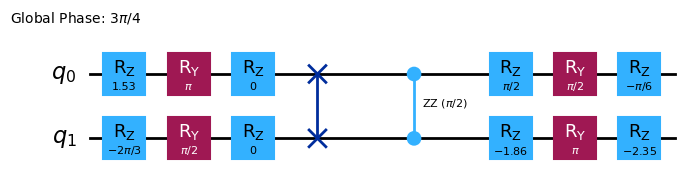

In [95]:
TwoQubitWeylDecomposition(Ax(1, 2)).circuit().draw('mpl')

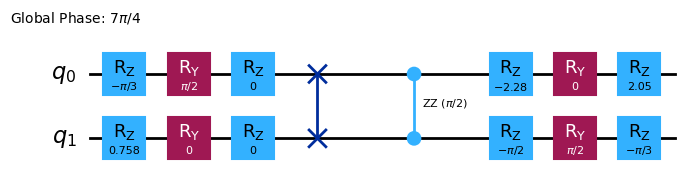

In [96]:
TwoQubitWeylDecomposition(By(1, 2)).circuit().draw('mpl')

In [ ]:
omega = np.exp(2*np.pi*1j/3)

def al(l):
    """
    Compute the coefficient alpha_l for the I_g Bell inequality sum.
    
    Args:
        l (int): Index (typically 1 or 2 for the two terms in I_g)
    
    Returns:
        complex: Coefficient α_l = ω^((2l-3)/8) / √2, where ω = exp(2πi/3)
    
    Notes:
        - Weighting coefficients for combining measurement correlations
        - Used in I_g computation: I_g = Σ α_l × (correlation terms)
        - Two main coefficients: al(1) and al(2) for two measurement rounds
    """
    return omega**((2 * l - 3)/8) / np.sqrt(2)

In [98]:
al(1)

np.complex128(0.6830127018922193-0.1830127018922193j)

In [ ]:
def Ig(qc):
    """
    Compute the I_g Bell inequality value from a quantum circuit state vector.
    
    Args:
        qc (QuantumCircuit): Circuit preparing the two-qutrit entangled state
    
    Returns:
        complex: I_g value (should be real for physical states)
    
    Notes:
        - Uses exact statevector simulation (no noise)
        - Computes 8 expectation values: ⟨A_x^(n) ⊗ B_y^(m)⟩ for:
          * First round: A_x(1,1), A_x(2,1) with B_y(1,2), B_y(2,2)
          * Second round: A_x(1,2), A_x(2,2) with B_y(1,1), B_y(2,1)
        - Combines using α₁, α₂ coefficients and ω phases
        - Classical bound for I_g is ~3.61; quantum states can exceed this
        - Assumes qutrit encoding on 4 qubits: two qutrits, each in 2-qubit subspace
    """
    sum = 0
    omega = np.exp(2*np.pi*1j/3)

    # First round of measurements: n=1 projectors
    A1 = Operator(Ax(1, 1))
    A2 = Operator(Ax(2, 1))
    B1 = Operator(By(1, 2))
    B2 = Operator(By(2, 2))

    a1 = al(1)
    a1cc = np.conjugate(a1)

    # Compute four correlation terms with appropriate phase factors
    op1 = a1 * Statevector(qc).expectation_value(A1 ^ B1)
    op2 = a1cc * omega * Statevector(qc).expectation_value(A1 ^ B2)
    op3 = a1 * Statevector(qc).expectation_value(A2 ^ B2)
    op4 = a1cc * Statevector(qc).expectation_value(A2 ^ B1)

    oplist = [op1, op2, op3, op4]

    for op in oplist:
        print(op.round(2))

    sum += np.sum(oplist)

    # Second round of measurements: n=2 projectors
    A12 = Operator(Ax(1, 2))
    A22 = Operator(Ax(2, 2))
    B12 = Operator(By(1, 1))
    B22 = Operator(By(2, 1))

    a2 = al(2)
    a2cc = np.conjugate(a2)

    # Compute four more correlation terms with different phase factors
    op1cc = a2 * Statevector(qc).expectation_value(A12 ^ B12)
    op2cc = a2cc * omega**2 * Statevector(qc).expectation_value(A12 ^ B22)
    op3cc = a2 * Statevector(qc).expectation_value(A22 ^ B22)
    op4cc = a2cc * Statevector(qc).expectation_value(A22 ^ B12)

    oplist2 = [op1cc, op2cc, op3cc, op4cc]

    for op2 in oplist2:
        print(op2.round(2))

    sum += np.sum(oplist2)

    return sum

In [ ]:
def Op(alfa, n):
    """
    Classical operator for local hidden variable (LHV) model.
    
    Args:
        alfa (int): Hidden variable value (0, 1, or 2 for qutrit)
        n (int): Measurement outcome power
    
    Returns:
        complex: ω^(n×α) where ω = exp(2πi/3)
    
    Notes:
        - Used to compute classical bound on I_g
        - Represents deterministic local response function
        - Part of search for maximum classical I_g value over all LHV strategies
    """
    omega = np.exp(2*np.pi*1j/3)
    return omega**(n*alfa)

In [ ]:
def I_g_clas(alfa1, alfa2, beta1, beta2):
    """
    Compute classical I_g value for given local hidden variable (LHV) strategy.
    
    Args:
        alfa1 (int): Alice's hidden variable for setting 1 (0, 1, or 2)
        alfa2 (int): Alice's hidden variable for setting 2 (0, 1, or 2)
        beta1 (int): Bob's hidden variable for setting 1 (0, 1, or 2)
        beta2 (int): Bob's hidden variable for setting 2 (0, 1, or 2)
    
    Returns:
        complex: I_g value for this deterministic strategy
    
    Notes:
        - Computes I_g using same formula as quantum case but with deterministic operators
        - Used to find maximum classical bound by brute-force search over all 3^4 strategies
        - Maximum classical value is ~3.61 (compared to quantum value up to 4.0)
        - LHV model: each party has pre-determined responses for all measurement settings
    """
    a1 = al(1)
    a1cc = np.conjugate(a1)
    a2 = al(2)
    a2cc = np.conjugate(a2)

    omega = np.exp(2*np.pi*1j/3)

    # Classical measurement outcomes for each setting and projector power
    A1 = Op(alfa1, 1)
    A2 = Op(alfa2, 1)
    B1 = Op(beta1, 2)
    B2 = Op(beta2, 2)
    A12 = Op(alfa1, 2)
    A22 = Op(alfa2, 2)
    B12 = Op(beta1, 1)
    B22 = Op(beta2, 1)
    return a1 * A1 * B1 + a1cc * omega * A1 * B2 + a1 * A2 * B2 + a1cc * A2 * B1 + a2 * A12 * B12 + a2cc * omega**2 * A12 * B22 + a2 * A22 * B22 + a2cc * A22 * B12

In [103]:
I_clas_max = I_g_clas(0, 0, 0, 0)
i_max = (0, 0, 0, 0)
for i in product(range(3), repeat=4):
    Itemp = I_g_clas(i[0], i[1], i[2], i[3])
    if Itemp > I_clas_max:
        I_clas_max = Itemp
        i_max = i

In [104]:
I_clas_max

np.complex128(3.098076211353316-6.661338147750939e-16j)

In [105]:
0.5 * (3 * (1 / np.tan(np.pi / (3 * 3))) - (1 / np.tan(3 * np.pi / (4 * 3))))

np.float64(3.621216129181934)

In [107]:
qc2, g2 = create_ame_circuit(2, 3)

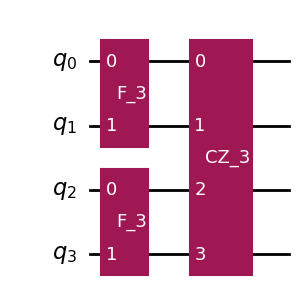

In [108]:
qc2.draw('mpl')

In [115]:
Operator(A1).draw('latex')

<IPython.core.display.Latex object>

In [116]:
Operator(B1).draw('latex')

<IPython.core.display.Latex object>

In [117]:
Operator(By(1, 1)).draw('latex')

<IPython.core.display.Latex object>

In [118]:
from IPython.display import display, Latex, Math

In [119]:
for i in product(range(2), repeat=2):
    display(Operator(By(i[0] + 1, i[1] + 1)).draw('latex'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [120]:
for i in product(range(2), repeat=2):
    display(Operator(Ax(i[0] + 1, i[1] + 1)).draw('latex'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [121]:
Btest = Operator(By(1,1))

In [122]:
((A1 ^ (Btest @ Btest)) @ Operator(qc2).data @ (A1 ^ (Btest @ Btest)).adjoint()).draw('latex')

<IPython.core.display.Latex object>

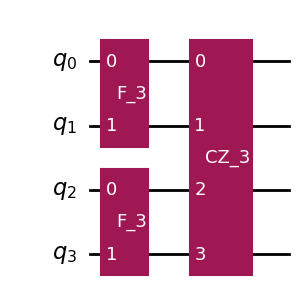

In [123]:
qc2.draw('mpl')

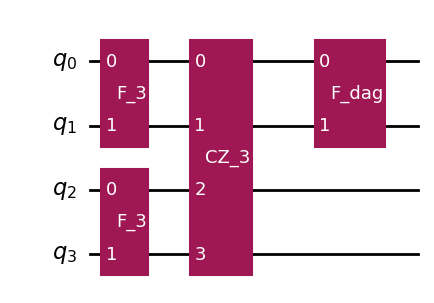

In [124]:
qc2 = create_ame_circuit(2, 3)[0]
qc2.append(FDAGgate3, [0, 1])
#qc2.append(Fgate3, [2, 3])
qc2.draw('mpl')

In [125]:
Statevector(qc2).draw('latex')

<IPython.core.display.Latex object>

In [126]:
np.trace(Operator(qc2).dot(A1 ^ (Btest.dot(Btest))))

np.complex128(2.2886751345948078-1.0773502691896288j)

In [127]:
Statevector(qc2).expectation_value(A1 ^ (Btest.dot(Btest)))

np.complex128(0.7440169358562919-0.04465819873852111j)

In [128]:
Ig(qc2)

(0.5-0.17j)
(0.5+0.17j)
(0.5-0.17j)
(0.5+0.17j)
(0.5+0.17j)
(0.5-0.17j)
(0.5+0.17j)
(0.5-0.17j)


np.complex128(3.9999999999999973-2.7478019859472624e-15j)

In [ ]:
def calculate_I_g(ev_list_re, ev_list_im):
    """
    Calculate I_g value from lists of real and imaginary expectation values.
    
    Args:
        ev_list_re (list): 8 real parts of expectation values ⟨A_x ⊗ B_y⟩
                          Order: [(A1,B1), (A1,B2), (A2,B2), (A2,B1), (A12,B12), (A12,B22), (A22,B22), (A22,B12)]
        ev_list_im (list): 8 imaginary parts of same expectation values
    
    Returns:
        complex: I_g value computed from weighted sum of correlations
    
    Notes:
        - Combines real and imaginary parts with appropriate α coefficients and ω phases
        - Used for processing hardware/simulation results where real/imaginary parts measured separately
        - Two rounds: first 4 values use al(1), last 4 use al(2)
        - Phase factors: ω for (A1,B2) term, ω² for (A12,B22) term
    """
    for im in [False, True]:
        if im:

In [ ]:
def calculate_I_g_std(std_list_re, std_list_im):
    """
    Calculate standard deviation (error) of I_g from measurement uncertainties.
    
    Args:
        std_list_re (list): 8 standard deviations for real parts of expectations
        std_list_im (list): 8 standard deviations for imaginary parts of expectations
    
    Returns:
        complex: Error estimate σ(I_g) = √(Σσ²_re) + i√(Σσ²_im)
    
    Notes:
        - Propagates errors through I_g calculation assuming independent measurements
        - Each term weighted by same α coefficients and ω phases as in I_g calculation
        - Quadrature sum: σ²_total = Σ(α × ω^k × σ_measurement)²
        - Separate calculation for real and imaginary parts
    """
    for im in [False, True]:
        if im:
            std_list = std_list_im
        else:
            std_list = std_list_re

        a1 = al(1)
        a1cc = np.conjugate(a1)

        # First round error terms
        op1 = (a1 * std_list[0])**2
        op2 = (a1cc * omega * std_list[1])**2
        op3 = (a1 * std_list[2])**2
        op4 = (a1cc * std_list[3])**2

        # Wyrazy dla n=2
        a2 = al(2)
        a2cc = np.conjugate(a2)

        # Second round error terms
        op1cc = (a2 * std_list[4])**2
        op2cc = (a2cc * omega**2 * std_list[5])**2
        op3cc = (a2 * std_list[6])**2
        op4cc = (a2cc * std_list[7])**2

        op_list = [op1, op2, op3, op4, op1cc, op2cc, op3cc, op4cc]

        if im:
            suma_im = sum(op_list)
        else:
            suma_re = sum(op_list)

    return np.sqrt(suma_re) + np.sqrt(suma_im)*1j

In [ ]:
def get_ind(n, m):
    """
    Map measurement setting pair (n,m) to index in ordered list.
    
    Args:
        n (int): Alice's measurement setting (1 or 2)
        m (int): Bob's measurement setting (1 or 2)
    
    Returns:
        tuple: (index, n, m) where index is position in standard ordering [(1,1), (1,2), (2,2), (2,1)]
    
    Notes:
        - Standard ordering matches correlation terms in I_g formula
        - Used to retrieve correct observable from pre-constructed operator lists
    """
    order = [(1, 1), (1, 2), (2, 2), (2, 1)]

    pos = {t:i for i,t in enumerate(order)}

    return pos[(n, m)], n, m

In [ ]:
def get_random_index():
    """
    Generate random measurement setting (1 or 2).
    
    Returns:
        int: Random choice of 1 or 2 with equal probability
    
    Notes:
        - Used for randomized measurement protocol to avoid detector loopholes
        - Each party independently chooses measurement setting randomly for each shot
        - Ensures fair sampling over all four setting combinations (1,1), (1,2), (2,1), (2,2)
    """
    rng = np.random.default_rng()
    res = rng.integers(2)
    return res + 1

In [ ]:
def create_isa_ops(base_qc):
    """
    Create Pauli observables for all measurement operators in ISA (instruction set architecture) basis.
    
    Args:
        base_qc (QuantumCircuit): Base circuit with layout information for ISA mapping
    
    Returns:
        tuple: Two lists [op_list_real, op_list_imag], [op2_list_real, op2_list_imag]
               - First list: observables for n=1 projectors (A_x(1), B_y(2))
               - Second list: observables for n=2 projectors (A_x(2), B_y(1))
               - Each list has real and imaginary parts separately
    
    Notes:
        - Converts A_x ⊗ B_y operators to SparsePauliOp for hardware execution
        - Real part: (AB + AB†)/2, Imaginary part: (AB - AB†)/(-2i)
        - Applies circuit layout to map logical qubits to physical qubits
        - Order: [(A1,B1), (A1,B2), (A2,B2), (A2,B1)] for both rounds
        - Hardware can only measure Pauli observables, not general Hermitian operators
    """
    A_list = [Ax(1, 1), Ax(2, 1)]
    B_list = [By(1, 2), By(2, 2)]
    A2_list = [Ax(1, 2), Ax(2, 2)]
    B2_list = [By(1, 1), By(2, 1)]

    op_list = []
    op2_list = []

    op_list_im = []
    op2_list_im = []
    for im in [False, True]:
        for ord in [(1, 1), (1, 2), (2, 2), (2, 1)]:
            n = ord[0] - 1
            m = ord[1] - 1

            A = A_list[n]
            B = B_list[m]

            A2 = A2_list[n]
            B2 = B2_list[m]

            AB = Operator(A) ^ Operator(B)
            AB2 = Operator(A2) ^ Operator(B2)
            
            # Extract real/imaginary parts as Hermitian operators
            if im:
                A_op = -0.5j * (AB - AB.adjoint())
                A2_op = -0.5j * (AB2 - AB2.adjoint())
            else:
                A_op = 0.5 * (AB + AB.adjoint())
                A2_op = 0.5 * (AB2 + AB2.adjoint())

            # Convert to Pauli basis for hardware measurement
            op = SparsePauliOp.from_operator(A_op)
            op2 = SparsePauliOp.from_operator(A2_op)

            # Apply layout mapping to physical qubits
            op_isa = op.apply_layout(layout=base_qc.layout)
            op2_isa = op2.apply_layout(layout=base_qc.layout)

            if im:
                op_list_im.append(op_isa)
                op2_list_im.append(op2_isa)
            else:
                op_list.append(op_isa)
                op2_list.append(op2_isa)

    return [op_list, op_list_im], [op2_list, op2_list_im]

In [ ]:
def AB_list(n, m, im, op):
    """
    Retrieve observable operator for given measurement settings.
    
    Args:
        n (int): Alice's measurement setting (1 or 2)
        m (int): Bob's measurement setting (1 or 2)
        im (bool): If True, return imaginary part observable; if False, return real part
        op (list): Operator list from create_isa_ops: [real_list, imag_list]
    
    Returns:
        tuple: (observable, n, m) where observable is SparsePauliOp for this setting combination
    
    Notes:
        - Selects appropriate observable from pre-computed operator lists
        - Used in randomized measurement protocol to pick observable for each shot
    """
    ind, n, m = get_ind(n, m)
    if im:
        Aret = op[1][ind]
    else:
        Aret = op[0][ind]
    return Aret, n, m

In [ ]:
def I_g_stat(qc, est, shots, op, op2):
    """
    Prepare random measurement protocol for I_g computation on hardware/simulator.
    
    Args:
        qc (QuantumCircuit): Quantum circuit preparing the two-qutrit state
        est (Estimator): Qiskit Estimator instance for expectation value measurement
        shots (int): Number of random measurement samples
        op (list): Observables for n=1 round from create_isa_ops
        op2 (list): Observables for n=2 round from create_isa_ops
    
    Returns:
        tuple: (job, n_list, m_list, ncc_list, mcc_list) where:
               - job: submitted Estimator job handle
               - n_list: Alice's settings for n=1 round (length = shots)
               - m_list: Bob's settings for n=1 round
               - ncc_list: Alice's settings for n=2 round  
               - mcc_list: Bob's settings for n=2 round
    
    Notes:
        - Randomized measurement protocol: each shot uses randomly chosen settings
        - "Oszustwo" (cheat): measures both n=1 and n=2 simultaneously per shot for efficiency
        - Each pub contains 4 observables: real(AB), real(AB2), imag(AB), imag(AB2)
        - Setting lists needed later to reconstruct I_g from randomized measurements
        - Avoids detector loophole by independent random choices per shot
    """
    pubs = []

    n_list, m_list, ncc_list, mcc_list = [], [], [], []

    for i in range(shots):
        # Randomly choose measurement settings for this shot
        n = get_random_index()
        m = get_random_index()

        ncc = get_random_index()
        mcc = get_random_index()

        #Tutaj jest oszustwo bo naraz mierze czesc n=1 i n=2
        # Get observables for randomly chosen settings
        AB, n, m = AB_list(n, m, False, op)
        ABcc, ncc, mcc = AB_list(ncc, mcc, False, op2)
        AB_im, n, m = AB_list(n, m, True, op)
        ABcc_im, ncc, mcc = AB_list(ncc, mcc, True, op2)

        #Tutaj jest oszustwo bo naraz mierze czesc n=1 i n=2
        # Create pub measuring all 4 observables simultaneously
        pubs.append((qc, [AB, ABcc, AB_im, ABcc_im]))

        # Record which settings were used
        n_list.append(n)
        m_list.append(m)

        ncc_list.append(ncc)
        mcc_list.append(mcc)

In [ ]:
def prepare_pubs(qc, shots, op, op2):
    """
    Prepare publication list (pubs) for randomized measurement protocol.
    
    Args:
        qc (QuantumCircuit): Circuit preparing the two-qutrit state
        shots (int): Number of random measurement samples
        op (list): Observables for n=1 round from create_isa_ops
        op2 (list): Observables for n=2 round from create_isa_ops
    
    Returns:
        tuple: (pubs, n_list, m_list, ncc_list, mcc_list)
               - pubs: list of (circuit, observables) pairs for Estimator
               - n_list, m_list, ncc_list, mcc_list: measurement setting records
    
    Notes:
        - Same as I_g_stat but returns pubs without submitting job
        - Used when need to prepare measurement tasks before execution
        - Allows batching/splitting pubs across multiple jobs
    """
    pubs = []

    n_list, m_list, ncc_list, mcc_list = [], [], [], []

    for i in range(shots):
        n = get_random_index()
        m = get_random_index()

        ncc = get_random_index()
        mcc = get_random_index()

        #Tutaj jest oszustwo bo naraz mierze czesc n=1 i n=2
        AB, n, m = AB_list(n, m, False, op)
        ABcc, ncc, mcc = AB_list(ncc, mcc, False, op2)
        AB_im, n, m = AB_list(n, m, True, op)
        ABcc_im, ncc, mcc = AB_list(ncc, mcc, True, op2)

        #Tutaj jest oszustwo bo naraz mierze czesc n=1 i n=2
        pubs.append((qc, [AB, ABcc, AB_im, ABcc_im]))

        n_list.append(n)
        m_list.append(m)

        ncc_list.append(ncc)
        mcc_list.append(mcc)

    return pubs, n_list, m_list, ncc_list, mcc_list

In [138]:
pubs = prepare_pubs(qc2, 10, op1, op2)[0]

In [139]:
job = est.run([pubs[0]])

In [ ]:
def I_g_stat(est, pub_cuts, shot, shots):  # shot, shots
    """
    Submit a batch of measurement pubs to Estimator and track progress.
    
    Args:
        est (Estimator): Qiskit Estimator instance for execution
        pub_cuts (list): List of (circuit, observables) pairs to measure
        shot (int): Current shot number (for progress display)
        shots (int): Total number of shots (for progress display)
    
    Returns:
        list: List containing single job handle [job]
    
    Notes:
        - Submits all pub_cuts in single job for efficiency
        - Returns list of one job to match interface expected by result processing
        - Displays progress counter during execution
    """
    parts = []

    print(f'Shots: {shot + 1} of {shots}')

    parts.append(est.run(pub_cuts))

    return parts

In [ ]:
def I_g_from_results(qc, est, shots, op, op2):
    """
    Complete workflow: prepare pubs, execute, and compute I_g from randomized measurements.
    
    Args:
        qc (QuantumCircuit): Circuit preparing the two-qutrit state
        est (Estimator): Qiskit Estimator for execution
        shots (int): Number of random measurement samples
        op (list): Observables for n=1 round
        op2 (list): Observables for n=2 round
    
    Returns:
        complex: I_g value reconstructed from randomized measurements
    
    Notes:
        - End-to-end function: prepares random protocol, submits job, processes results
        - Groups results by setting combination (n,m) and averages
        - Handles both n=1 and n=2 rounds, real and imaginary parts
        - Reconstructs 8 expectation values in standard order for calculate_I_g
        - May have missing setting combinations if shots too small (returns None for those)
    """
    results, n_list, m_list, ncc_list, mcc_list = I_g_stat(qc, est, shots, op, op2)

    # Collect results by setting combination
    ev_dict_re = {}
    ev_dict_im = {}

    for res, n, m, ncc, mcc in zip(range(len(results)), n_list, m_list, ncc_list, mcc_list):
        ev = results[res].data.evs[0]
        key_re = (0, n, m)

        if key_re not in ev_dict_re:
            ev_dict_re[key_re] = []
        ev_dict_re[key_re].append(ev)

        evcc = results[res].data.evs[1]
        key_cc = (1, ncc, mcc)
        if key_cc not in ev_dict_re:
            ev_dict_re[key_cc] = []
        ev_dict_re[key_cc].append(evcc)

        # dla IM
        ev_im = results[res].data.evs[2]
        key_re_im = (0, n, m)

        if key_re_im not in ev_dict_im:
            ev_dict_im[key_re_im] = []
        ev_dict_im[key_re_im].append(ev_im)

        evcc_im = results[res].data.evs[3]
        key_cc_im = (1, ncc, mcc)

        if key_cc_im not in ev_dict_im:
            ev_dict_im[key_cc_im] = []
        ev_dict_im[key_cc_im].append(evcc_im)

    # Average results for each setting combination
    mean_ev_list = {}

    for key in ev_dict_re:
        mean_ev_list[key] = np.mean(ev_dict_re[key])

    print(len(mean_ev_list.keys()))

    # Reconstruct expectation value list in standard order
    final_ev_list_re = []

    for ord in [(1, 1), (1, 2), (2, 2), (2, 1)]:
            final_ev_list_re.append(mean_ev_list.get((0, ord[0], ord[1])))

    for ord in [(1, 1), (1, 2), (2, 2), (2, 1)]:
            final_ev_list_re.append(mean_ev_list.get((1, ord[0], ord[1])))

    mean_ev_list_im = {}

    for key in ev_dict_im:
        mean_ev_list_im[key] = np.mean(ev_dict_im[key])

    final_ev_list_im = []

    for ord in [(1, 1), (1, 2), (2, 2), (2, 1)]:
        final_ev_list_im.append(mean_ev_list_im.get((0, ord[0], ord[1])))

    for ord in [(1, 1), (1, 2), (2, 2), (2, 1)]:
        final_ev_list_im.append(mean_ev_list_im.get((1, ord[0], ord[1])))

    print("Len re", len(final_ev_list_re))
    print("Len im", len(final_ev_list_im))

    ig_val = calculate_I_g(final_ev_list_re, final_ev_list_im)

    return ig_val

In [142]:
from itertools import chain

In [ ]:
def I_g_from_results_with_std(parts, n_list, m_list, ncc_list, mcc_list):
    """
    Compute I_g and error bars from job results with randomized measurements.
    
    Args:
        parts (list): List of job handles (each job.result() returns list of PrimitiveResult)
        n_list (list): Alice's settings for n=1 round (one per measurement)
        m_list (list): Bob's settings for n=1 round
        ncc_list (list): Alice's settings for n=2 round
        mcc_list (list): Bob's settings for n=2 round
    
    Returns:
        tuple: (I_g_value, I_g_error) both as complex numbers
    
    Notes:
        - Flattens results from multiple jobs using itertools.chain
        - Groups measurements by setting (channel, n, m) and averages
        - Computes standard error: σ_mean = √(mean(σ²)) / √N for each setting
        - Propagates errors through I_g calculation
        - Validates all 8 setting combinations present (reports missing keys)
        - Channel 0 = n=1 round, Channel 1 = n=2 round
    """
    # Flatten results from all jobs
    results = list(chain.from_iterable([p.result() for p in parts]))

    from collections import defaultdict
    ev_re = defaultdict(list)  # keys: (chan, n, m, l)
    ev_im = defaultdict(list)
    std_re = defaultdict(list)
    std_im = defaultdict(list)

    # Collect expectation values and errors grouped by settings
    for idx, res in enumerate(results):
        evs = res.data.evs
        stds = res.data.stds
        ev_re[(0, n_list[idx],   m_list[idx])].append(evs[0])
        ev_re[(1, ncc_list[idx], mcc_list[idx])].append(evs[1])
        std_re[(0, n_list[idx],   m_list[idx])].append(stds[0]**2)
        std_re[(1, ncc_list[idx], mcc_list[idx])].append(stds[1]**2)

        ev_im[(0, n_list[idx],   m_list[idx])].append(evs[2])
        ev_im[(1, ncc_list[idx], mcc_list[idx])].append(evs[3])
        std_im[(0, n_list[idx],   m_list[idx])].append(stds[2]**2)
        std_im[(1, ncc_list[idx], mcc_list[idx])].append(stds[3]**2)


    # 2) Średnie
    import numpy as np
    # Compute mean expectation values and standard errors
    mean_re = {k: float(np.mean(v)) for k, v in ev_re.items()}
    mean_im = {k: float(np.mean(v)) for k, v in ev_im.items()}
    mean_re_std = {k: float(np.sqrt(np.mean(v)) / len(v)) for k, v in std_re.items()}
    mean_im_std = {k: float(np.sqrt(np.mean(v)) / len(v)) for k, v in std_im.items()}

    order_base = [(1, 1), (1, 2), (2, 2), (2, 1)]

    order_cc = order_base  # <-- zmień, jeśli CC ma inny układ trójek!

    # Gather values in standard order, track missing setting combinations
    def gather(means_dict, chan, order):
        vals, missing = [], []
        for (n,m) in order:
            key = (chan, n, m)
            if key not in means_dict:
                missing.append(key)
                vals.append(None)
            else:
                vals.append(means_dict[key])
        return vals, missing

    re_main, miss_re0 = gather(mean_re, 0, order_base)
    re_cc,   miss_re1 = gather(mean_re, 1, order_cc)
    im_main, miss_im0 = gather(mean_im, 0, order_base)
    im_cc,   miss_im1 = gather(mean_im, 1, order_cc)

    re_main_std, miss_re0_std = gather(mean_re_std, 0, order_base)
    re_cc_std,   miss_re1_std = gather(mean_re_std, 1, order_cc)
    im_main_std, miss_im0_std = gather(mean_im_std, 0, order_base)
    im_cc_std,   miss_im1_std = gather(mean_im_std, 1, order_cc)

    # Combine into final lists for I_g calculation
    final_ev_list_re = re_main + re_cc
    final_ev_list_im = im_main + im_cc

    final_std_list_re = re_main_std + re_cc_std
    final_std_list_im = im_main_std + im_cc_std

    ig_val = calculate_I_g(final_ev_list_re, final_ev_list_im)
    std_val = calculate_I_g_std(final_std_list_re, final_std_list_im)

In [144]:
est = AerEstimator()

In [145]:
op1, op2 = create_isa_ops(qc2)

In [ ]:
def Ry01(theta):
    """
    Rotation operator between qutrit levels |0⟩ and |1⟩.
    
    Args:
        theta (float): Rotation angle in radians
    
    Returns:
        Operator: 4x4 operator implementing rotation in |00⟩-|01⟩ subspace
    
    Notes:
        - Acts on 2-qubit qutrit encoding: rotates |00⟩ ↔ |01⟩
        - Leaves |10⟩ (qutrit level |2⟩) and |11⟩ (leakage) unchanged
        - Used to scan I_g as function of state parameter
    """
    mtx = np.array([
        [np.cos(theta/2), -np.sin(theta/2), 0, 0],
        [np.sin(theta/2), np.cos(theta/2), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])
    return Operator(mtx)

def Ry02(theta):
    """
    Rotation operator between qutrit levels |0⟩ and |2⟩.
    
    Args:
        theta (float): Rotation angle in radians
    
    Returns:
        Operator: 4x4 operator implementing rotation in |00⟩-|10⟩ subspace
    
    Notes:
        - Acts on 2-qubit qutrit encoding: rotates |00⟩ ↔ |10⟩
        - Leaves |01⟩ (qutrit level |1⟩) and |11⟩ (leakage) unchanged
        - Used to scan I_g as function of state parameter
    """
    mtx = np.array([
        [np.cos(theta/2),   0, -np.sin(theta/2),    0],
        [0,                 1, 0,                   0],
        [np.sin(theta/2),   0, np.cos(theta/2),     0],
        [0,                 0, 0,                   1]
    ])
    return Operator(mtx)

def Ry12(theta):
    """
    Rotation operator between qutrit levels |1⟩ and |2⟩.
    
    Args:
        theta (float): Rotation angle in radians
    
    Returns:
        Operator: 4x4 operator implementing rotation in |01⟩-|10⟩ subspace
    
    Notes:
        - Acts on 2-qubit qutrit encoding: rotates |01⟩ ↔ |10⟩
        - Leaves |00⟩ (qutrit level |0⟩) and |11⟩ (leakage) unchanged
        - Used to scan I_g as function of state parameter
    """
    mtx = np.array([
        [1, 0, 0, 0],
        [0, np.cos(theta/2), -np.sin(theta/2), 0],
        [0, np.sin(theta/2), np.cos(theta/2), 0],
        [0, 0, 0, 1]
    ])
    return Operator(mtx)

In [ ]:
def prepare_chsh(start, stop, resolution, qc):
    """
    Prepare circuits and observables for CHSH-style parameter scan.
    
    Args:
        start (float): Starting angle (in radians)
        stop (float): Ending angle (in radians)
        resolution (int): Number of points to sample
        qc (QuantumCircuit): Base circuit preparing two-qutrit state
    
    Returns:
        tuple: (qc01_list, theta_list, oplist1, oplist2) where:
               - qc01_list: circuits with Ry01 rotation applied and transpiled
               - theta_list: array of theta values
               - oplist1: observables for n=1 round (one per theta)
               - oplist2: observables for n=2 round (one per theta)
    
    Notes:
        - Scans I_g(θ) by applying Ry01(θ) rotation to first qutrit
        - Each circuit transpiled to ISA for hardware execution
        - Observables recomputed per circuit due to layout changes
        - Used to find maximum I_g and verify Bell inequality violation
    """
    theta_list = np.linspace(start, stop, resolution)

    # Generate rotation operators
    ry01_list = [Ry01(theta) for theta in theta_list]
    ry01_qc_list = [TwoQubitWeylDecomposition(ry).circuit() for ry in ry01_list]

    for ry in ry01_qc_list:
        ry.name = "Ry01"

    oplist1 = []
    oplist2 = []

    qc01_list = []
    for ry in ry01_qc_list:
        # Append rotation and transpile for hardware
        qctemp = qc.copy()
        qctemp.append(ry, [0, 1])
        qctemp_isa = pm.run(qctemp)
        print(qctemp_isa.depth())
        
        # Create observables for this transpiled circuit
        op1, op2 = create_isa_ops(qctemp_isa)
        oplist1.append(op1)
        oplist2.append(op2)
        qc01_list.append(qctemp_isa)

    return qc01_list, theta_list, oplist1, oplist2

In [ ]:
def chsh_pub_cuts(qc01_list, oplist, oplist2, shots):
    """
    Prepare pubs for all theta values in parameter scan.
    
    Args:
        qc01_list (list): Circuits for each theta (from prepare_chsh)
        oplist (list): n=1 observables for each theta
        oplist2 (list): n=2 observables for each theta
        shots (int): Number of random measurements per theta
    
    Returns:
        tuple: (pub_cuts_list, n_list_list, m_list_list, ncc_list_list, mcc_list_list)
               - pub_cuts_list: list of pub lists (one per theta value)
               - *_list_list: measurement settings (outer list = theta, inner list = shots)
    
    Notes:
        - Generates random measurement protocol for each theta point
        - Returns nested lists: pub_cuts_list[i] = pubs for i-th theta value
        - Setting lists needed later to reconstruct I_g from results
    """
    pub_cuts_list = []

    n_list_list = []
    m_list_list = []

In [ ]:
def chsh_jobs(est, pub_cuts_list, res):
    """
    Submit measurement jobs for all theta values in CHSH scan.
    
    Args:
        est (Estimator): Qiskit Estimator for job execution
        pub_cuts_list (list): Nested list of pubs (one inner list per theta)
        res (int): Resolution (number of theta points) for progress display
    
    Returns:
        list: parts_list where parts_list[i] = job handles for i-th theta value
    
    Notes:
        - Submits one job per theta value
        - Displays progress: "Shots: k of res"
        - Returns nested structure matching input pub_cuts_list
    """
    parts_list = []

    for pub_cuts, k in zip(pub_cuts_list, range(len(pub_cuts_list))):
        parts = I_g_stat(est, pub_cuts, k, res)
        parts_list.append(parts)

    return parts_list

In [ ]:
def chsh_results(parts_list, n_list_list, m_list_list, ncc_list_list, mcc_list_list):
    """
    Process job results for all theta values and compute I_g with errors.
    
    Args:
        parts_list (list): Job handles for each theta (from chsh_jobs)
        n_list_list (list): Nested measurement settings (from chsh_pub_cuts)
        m_list_list (list): Nested measurement settings
        ncc_list_list (list): Nested measurement settings
        mcc_list_list (list): Nested measurement settings
    
    Returns:
        tuple: (igval_list, stds_list) where:
               - igval_list: I_g values for each theta
               - stds_list: absolute errors |σ(I_g)| for each theta
    
    Notes:
        - Processes results for all theta points
        - Prints I_g value as each is computed
        - Returns only real part of I_g (should be real for physical states)
    """
    igval_list = []
    stds_list = []

    for parts, n_list, m_list, ncc_list, mcc_list in zip(parts_list, n_list_list, m_list_list, ncc_list_list, mcc_list_list):
        ig, stds = I_g_from_results_with_std(parts, n_list, m_list, ncc_list, mcc_list)
        print(ig)
        igval_list.append(ig)
        stds_list.append(np.abs(stds))

    return igval_list, stds_list

In [ ]:
def chsh_plot(igval_list, stds_list, theta_list):
    """
    Plot I_g values vs theta with error bars.
    
    Args:
        igval_list (list): I_g values for each theta
        stds_list (list): Error bars for each theta
        theta_list (array): Theta values in radians
    
    Notes:
        - X-axis in units of π
        - Horizontal dashed line at 3.621 (classical bound)
        - Red points with error bars showing quantum violation
        - Label indicates Ry01 rotation was used
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.errorbar(
        theta_list / np.pi,
        np.real(igval_list),
        yerr=stds_list,
        fmt="o-",                 
        capsize=5,                
        color="red",
        label="Ry01"
    )
    ax.axhline(y=3.621, linestyle="--")
    ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
    plt.xlabel("Theta")
    plt.ylabel("Imax")
    plt.legend()
    plt.show()

In [ ]:
def chsh(start, stop, resolution, est, qc, shots, session=False):
    """
    Complete CHSH-style parameter scan: prepare, execute, process, and plot I_g(θ).
    
    Args:
        start (float): Starting theta angle in radians
        stop (float): Ending theta angle in radians
        resolution (int): Number of theta points to sample
        est (Estimator): Qiskit Estimator (or create one in session)
        qc (QuantumCircuit): Base two-qutrit circuit
        shots (int): Number of random measurements per theta
        session (bool): If True, create IBM Quantum session with error mitigation
    
    Returns:
        tuple: (igval_list, stds_list, theta_list) - results and parameters
    
    Notes:
        - Full workflow: calls prepare_chsh, chsh_pub_cuts, chsh_jobs, chsh_results, chsh_plot
        - Saves measurement settings to "listy_pomiar.txt" for debugging
        - If session=True: creates Session with Estimator, 100 shots, resilience level 2
        - Displays plot showing I_g vs theta with classical bound
        - Returns data for further analysis
    """
    qc01_list, theta_list, oplist, oplist2 = prepare_chsh(start, stop, resolution, qc)
    pub_cuts_list, n_list_list, m_list_list, ncc_list_list, mcc_list_list = chsh_pub_cuts(qc01_list, oplist, oplist2, shots)

    with open("listy_pomiar.txt", "w") as f:
        f.write(f'NLIST: {n_list_list}\n MLIST: {m_list_list}\n NCCLIST: {ncc_list_list}\n MCCLIST: {mcc_list_list}\n')

    if session:
        with Session(backend=backend) as session:
            est = Estimator()
            est.options.default_shots = 100
            est.resilience_level = 2

            parts_list = chsh_jobs(est, pub_cuts_list, resolution)

        print("End of session")
    else:
        parts_list = chsh_jobs(est, pub_cuts_list, resolution)
    igval_list, stds_list = chsh_results(parts_list, n_list_list, m_list_list, ncc_list_list, mcc_list_list)
    chsh_plot(igval_list, stds_list, theta_list)

In [69]:
qc01_list, theta_list, oplist, oplist2 = prepare_chsh(1, 2, 3, qc2)

93
93
93


In [72]:
pub_cuts_list, n_list_list, m_list_list, ncc_list_list, mcc_list_list = chsh_pub_cuts(qc01_list, oplist, oplist2, 30)

In [81]:
est = AerEstimator()
job = est.run(pub_cuts_list[0])
res = job.result()

In [172]:
backend = QiskitRuntimeService().backend("ibm_kingston")
target = backend.target

qiskit_runtime_service._resolve_cloud_instances:WARNING:2025-10-12 20:25:00,618: Default instance not set. Searching all available instances.


In [173]:
pm = generate_preset_pass_manager(target=target, optimization_level=3)

82
92
91
91
91
92
92
92
92
91
91
92
91
91
92
92
91
92
91
82
[-6.28318531 -5.62179738 -4.96040945 -4.29902153 -3.6376336  -2.97624567
 -2.31485774 -1.65346982 -0.99208189 -0.33069396  0.33069396  0.99208189
  1.65346982  2.31485774  2.97624567  3.6376336   4.29902153  4.96040945
  5.62179738  6.28318531]
Shots: 1 of 20 | splitting into 1 jobs
Shots: 2 of 20 | splitting into 1 jobs
Shots: 3 of 20 | splitting into 1 jobs
Shots: 4 of 20 | splitting into 1 jobs
Shots: 5 of 20 | splitting into 1 jobs
Shots: 6 of 20 | splitting into 1 jobs
Shots: 7 of 20 | splitting into 1 jobs
Shots: 8 of 20 | splitting into 1 jobs
Shots: 9 of 20 | splitting into 1 jobs
Shots: 10 of 20 | splitting into 1 jobs
Shots: 11 of 20 | splitting into 1 jobs
Shots: 12 of 20 | splitting into 1 jobs
Shots: 13 of 20 | splitting into 1 jobs
Shots: 14 of 20 | splitting into 1 jobs
Shots: 15 of 20 | splitting into 1 jobs
Shots: 16 of 20 | splitting into 1 jobs
Shots: 17 of 20 | splitting into 1 jobs
Shots: 18 of 20 | splitt

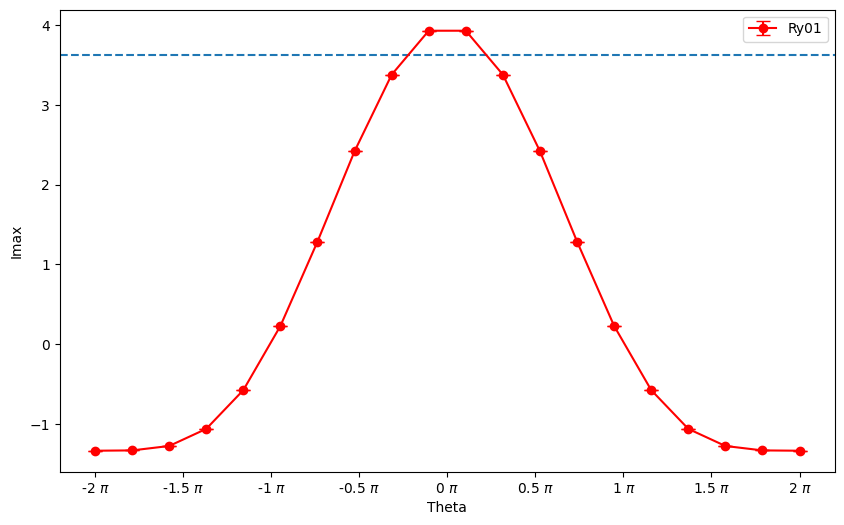

In [256]:
igval_sim, stds_sim, thetha_list_sim = chsh(-2 * np.pi, 2 * np.pi, 20, est, qc2.decompose().decompose().decompose(), 30, session=False)

In [257]:
igval_sim

[np.complex128(-1.3333333333333282+8.118505867571457e-16j),
 np.complex128(-1.3294189716040925+8.604228440844963e-16j),
 np.complex128(-1.2740510336298425+6.869504964868156e-16j),
 np.complex128(-1.059658704761779+8.81239525796218e-16j),
 np.complex128(-0.5742771331797869+6.349087922075114e-16j),
 np.complex128(0.22930405232440848+2.220446049250313e-16j),
 np.complex128(1.286333417990762-4.2847669856627135e-16j),
 np.complex128(2.417697960687094-1.074661193367632e-15j),
 np.complex128(3.376562108632262-1.6219664500383146e-15j),
 np.complex128(3.927508303541015-2.0365653607967715e-15j),
 np.complex128(3.9275083035410168-1.9741153156616065e-15j),
 np.complex128(3.3765621086322555-1.8023776915399026e-15j),
 np.complex128(2.4176979606870885-1.190887666258078e-15j),
 np.complex128(1.286333417990757-7.37257477290143e-16j),
 np.complex128(0.229304052324404-3.729655473350135e-17j),
 np.complex128(-0.574277133179792+4.128641872824801e-16j),
 np.complex128(-1.059658704761783+5.48172618408671e-16

89
88
89
88
108
89
89
88
89
88
1 of 10, Jobs num: 1
1 of 10, Jobs num: 2
1 of 10, Jobs num: 3
1 of 10, Jobs num: 4
1 of 10, Jobs num: 5
1 of 10, Jobs num: 6
1 of 10, Jobs num: 7
1 of 10, Jobs num: 8
1 of 10, Jobs num: 9
1 of 10, Jobs num: 10
1 of 10, Jobs num: 11
1 of 10, Jobs num: 12
1 of 10, Jobs num: 13
1 of 10, Jobs num: 14
1 of 10, Jobs num: 15
1 of 10, Jobs num: 16
1 of 10, Jobs num: 17
1 of 10, Jobs num: 18
1 of 10, Jobs num: 19
1 of 10, Jobs num: 20
1 of 10, Jobs num: 21
1 of 10, Jobs num: 22
1 of 10, Jobs num: 23
1 of 10, Jobs num: 24
1 of 10, Jobs num: 25
1 of 10, Jobs num: 26
1 of 10, Jobs num: 27
1 of 10, Jobs num: 28
1 of 10, Jobs num: 29
1 of 10, Jobs num: 30
1 of 10, Jobs num: 31
1 of 10, Jobs num: 32
1 of 10, Jobs num: 33
1 of 10, Jobs num: 34
1 of 10, Jobs num: 35
1 of 10, Jobs num: 36
1 of 10, Jobs num: 37
1 of 10, Jobs num: 38
1 of 10, Jobs num: 39
1 of 10, Jobs num: 40
1 of 10, Jobs num: 41
1 of 10, Jobs num: 42
1 of 10, Jobs num: 43
1 of 10, Jobs num: 44
1 of 10, J

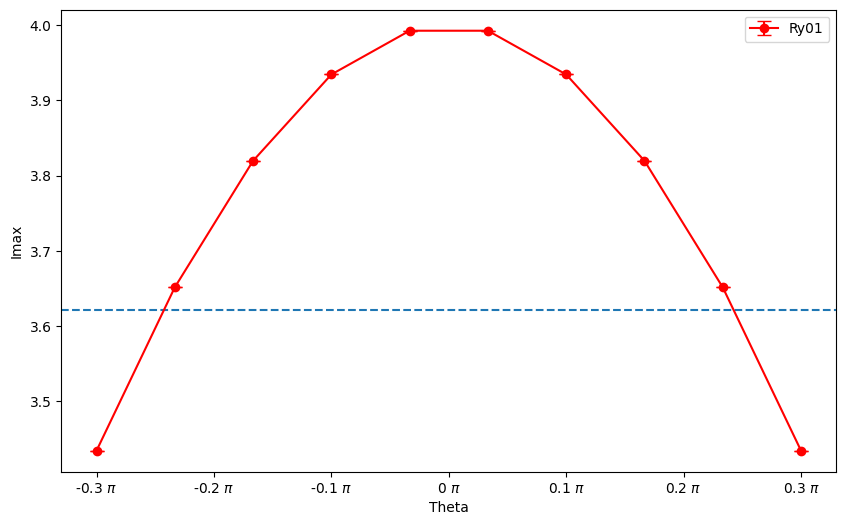

In [65]:
igval, stds, thetha_list = chsh(-0.3 * np.pi, 0.3 * np.pi, 10, est, qc2.decompose().decompose().decompose(), 50, session=False)

In [ ]:
igval, stds, thetha_list = chsh(-0.3 * np.pi, 0.3 * np.pi, 5, est, qc2, 30, session=True)

97
77
70
78
78
Shots: 1 of 5
Shots: 2 of 5
Shots: 3 of 5
Shots: 4 of 5
Shots: 5 of 5


94
96
87
95
94
Shots: 1 of 5
Shots: 2 of 5
Shots: 3 of 5
Shots: 4 of 5
Shots: 5 of 5
(3.4345408993639666-1.9463597400459776e-15j)
(3.853657470519381-2.0296264668928643e-15j)
(4.000000000000004-2.0122792321330962e-15j)
(3.8536574705193827-2.0088097851811426e-15j)
(3.4345408993639706-1.7555401576885288e-15j)


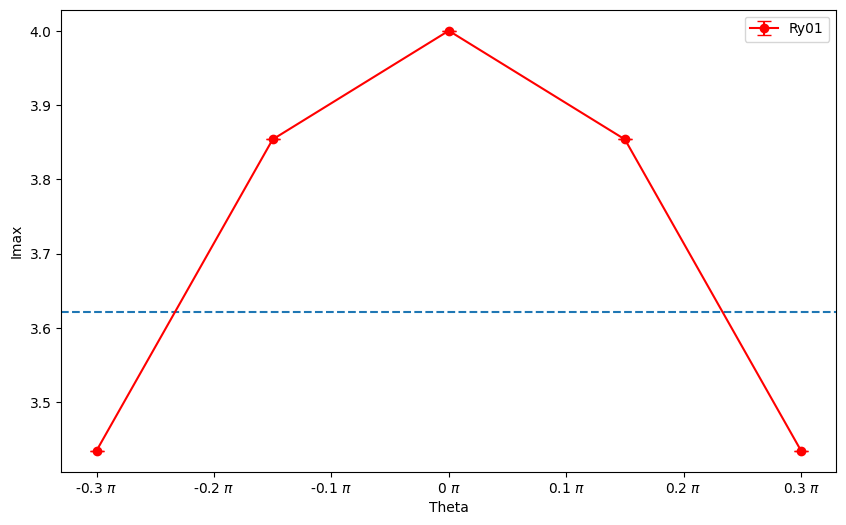

In [78]:
igval, stds, thetha_list = chsh(-0.3 * np.pi, 0.3 * np.pi, 5, est, qc2, 20, session=False)

In [ ]:
from itertools import chain

def split_equal(seq, parts):
    """
    Split sequence into 'parts' chunks as equal as possible without losing elements.
    
    Args:
        seq (list): Sequence to split
        parts (int): Number of chunks (must be >= 1)
    
    Returns:
        list: List of chunks (sublists), each non-empty
    
    Notes:
        - Distributes elements evenly: first (n mod parts) chunks get one extra element
        - Example: split_equal([1,2,3,4,5], 3) → [[1,2], [3,4], [5]]
        - Used to split pubs across multiple jobs for parallel execution
    """
    parts = max(1, int(parts))
    n = len(seq)
    k, m = divmod(n, parts)
    out = []
    start = 0
    for i in range(parts):
        end = start + k + (1 if i < m else 0)
        out.append(seq[start:end])
        start = end
    return [chunk for chunk in out if chunk]

In [ ]:
def I_g_stat(est, pub_cuts, shot, shots, *, div_jobs=1):
    """
    Submit measurement jobs for one theta, optionally splitting across multiple jobs.
    
    Args:
        est (Estimator): Qiskit Estimator for execution
        pub_cuts (list): Pubs for this theta value
        shot (int): Current theta index (for progress display)
        shots (int): Total number of theta values (for progress display)
        div_jobs (int): Number of jobs to split pubs into (default 1)
    
    Returns:
        list: Job handles (length 1 if div_jobs=1, else length div_jobs)
    
    Notes:
        - If div_jobs > 1: splits pub_cuts into chunks and submits separate jobs
        - Useful to work around job size limits or parallelize execution
        - Results later flattened by I_g_from_results_with_std using itertools.chain
        - Display: "Shots: k of N | splitting into M jobs"
    """
    print(f'Shots: {shot + 1} of {shots} | splitting into {div_jobs} jobs')

    parts = []
    if div_jobs <= 1 or len(pub_cuts) <= 1:
        parts.append(est.run(pub_cuts))
        return parts

    for chunk in split_equal(pub_cuts, div_jobs):
        parts.append(est.run(chunk))
    return parts

In [ ]:
def chsh_jobs(est, pub_cuts_list, res, *, div_jobs=1):
    """
    Submit jobs for all theta values with optional job splitting.
    
    Args:
        est (Estimator): Qiskit Estimator
        pub_cuts_list (list): Nested list of pubs (one per theta)
        res (int): Number of theta values (resolution)
        div_jobs (int): Number of jobs per theta (default 1)
    
    Returns:
        list: parts_list where parts_list[i] = list of job handles for theta i
    
    Notes:
        - Extension of chsh_jobs with div_jobs parameter
        - Each theta's pubs can be split across multiple jobs
        - Useful for large experiments exceeding job size limits
    """
    parts_list = []
    for pub_cuts, k in zip(pub_cuts_list, range(len(pub_cuts_list))):
        parts = I_g_stat(est, pub_cuts, k, res, div_jobs=div_jobs)
        parts_list.append(parts)
    return parts_list

In [254]:
def chsh(start, stop, resolution, est, qc, shots, session=False, div_jobs=1):
    qc01_list, theta_list, oplist, oplist2 = prepare_chsh(start, stop, resolution, qc)
    pub_cuts_list, n_list_list, m_list_list, ncc_list_list, mcc_list_list = chsh_pub_cuts(qc01_list, oplist, oplist2, shots)
    print(theta_list)
    with open("listy_pomiar.txt", "w") as f:
        f.write(f'NLIST: {n_list_list}\n MLIST: {m_list_list}\n NCCLIST: {ncc_list_list}\n MCCLIST: {mcc_list_list}\n')

    if session:
        with Session(backend=backend) as session:
            est = Estimator()
            est.options.default_shots = 500
            est.options.resilience_level = 2

            parts_list = chsh_jobs(est, pub_cuts_list, resolution, div_jobs=div_jobs)

        print("End of session")
    else:
        parts_list = chsh_jobs(est, pub_cuts_list, resolution, div_jobs=div_jobs)
    igval_list, stds_list = chsh_results(parts_list, n_list_list, m_list_list, ncc_list_list, mcc_list_list)
    chsh_plot(igval_list, stds_list, theta_list)
    return igval_list, stds_list, theta_list

94
95
87
96
94
Shots: 1 of 5 | splitting into 10 jobs
Shots: 2 of 5 | splitting into 10 jobs
Shots: 3 of 5 | splitting into 10 jobs
Shots: 4 of 5 | splitting into 10 jobs
Shots: 5 of 5 | splitting into 10 jobs
(3.4345408993639652-1.7590096046404824e-15j)
(3.8536574705193853-1.863093013199091e-15j)
(4.000000000000004-2.067790383364354e-15j)
(3.8536574705193827-2.175343238874916e-15j)
(3.4345408993639706-1.8110513089197866e-15j)


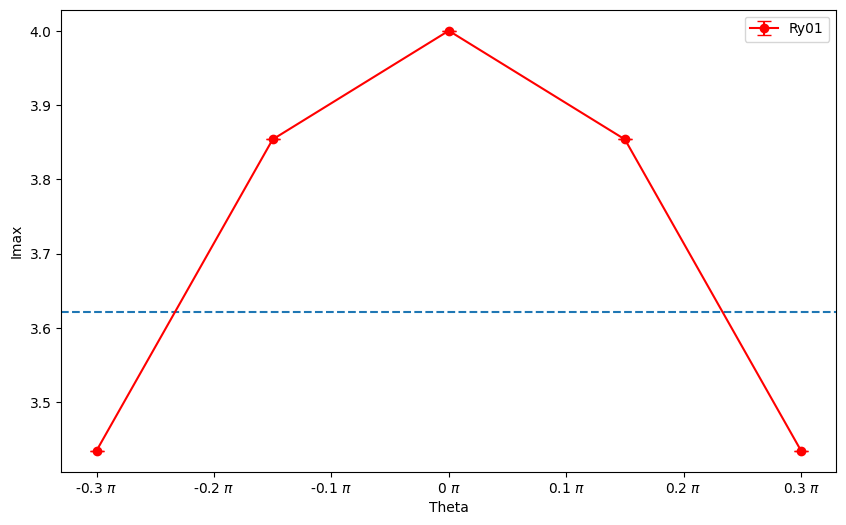

In [211]:
igval, stds, thetha_list = chsh(-0.3 * np.pi, 0.3 * np.pi, 5, est, qc2, 30, session=False, div_jobs=10)

119
97
87
97
95
Shots: 1 of 5 | splitting into 10 jobs
Shots: 2 of 5 | splitting into 10 jobs
Shots: 3 of 5 | splitting into 10 jobs
Shots: 4 of 5 | splitting into 10 jobs
Shots: 5 of 5 | splitting into 10 jobs
(3.60174994082113-1.824929096727601e-15j)
(3.8980137694161416-1.9463597400459776e-15j)
(4.000000000000003-2.022687572988957e-15j)
(3.8980137694161447-2.2516710718178956e-15j)
(3.6017499408211324-1.717376241217039e-15j)


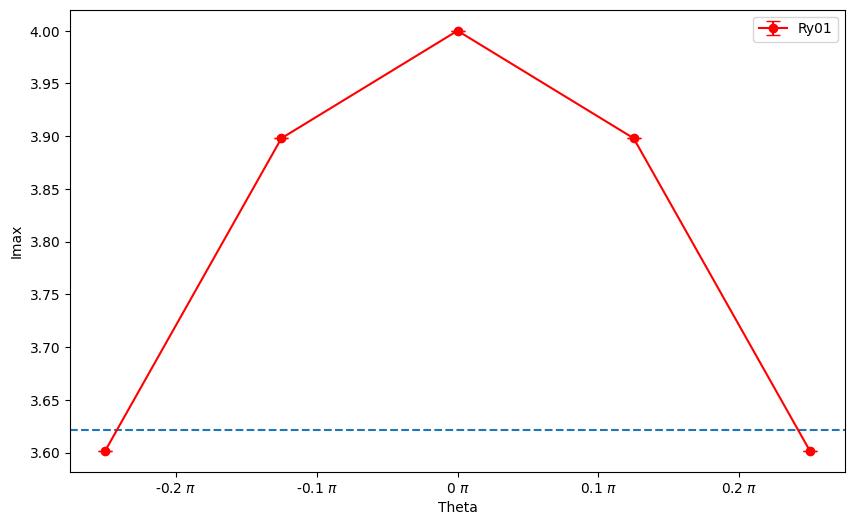

In [174]:
igval, stds, thetha_list = chsh(-0.25 * np.pi, 0.25 * np.pi, 5, est, qc2, 30, session=False, div_jobs=10)

97
94
87
94
96
Shots: 1 of 5 | splitting into 10 jobs
Shots: 2 of 5 | splitting into 10 jobs
Shots: 3 of 5 | splitting into 10 jobs
Shots: 4 of 5 | splitting into 10 jobs
Shots: 5 of 5 | splitting into 10 jobs
End of session
(3.712140113286048+0.07487193490326609j)
(nan+nanj)
(nan+nanj)
(nan+nanj)
(nan+nanj)


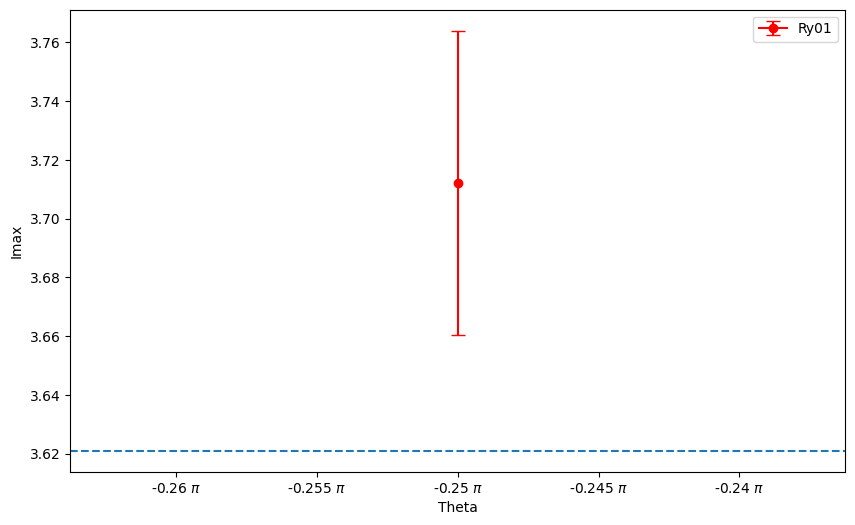

In [175]:
igval, stds, thetha_list = chsh(-0.25 * np.pi, 0.25 * np.pi, 5, est, qc2, 30, session=True, div_jobs=10)

87
[0.]
Shots: 1 of 1 | splitting into 10 jobs
End of session
(4.029978242545959-0.006568281851398752j)


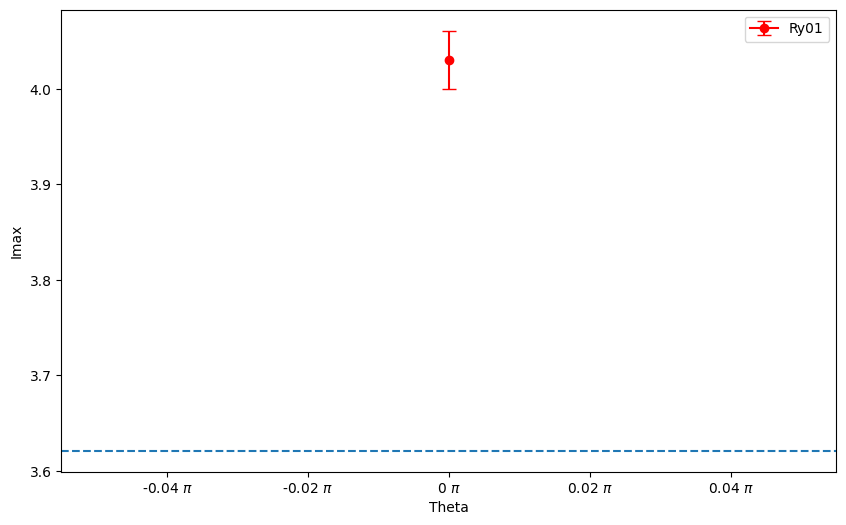

In [255]:
igval_0, stds_0, thetha_list_0 = chsh(0, 1, 1, est, qc2, 30, session=True, div_jobs=10)

In [ ]:
from itertools import chain
import csv
from qiskit_ibm_runtime import QiskitRuntimeService

def read_job_ids_from_csv(path: str) -> list[str]:
    """
    Read job IDs from CSV file exported from IBM Quantum session.
    
    Args:
        path (str): Path to CSV file with 'JobId' column
    
    Returns:
        list: Job IDs in same order as in CSV file
    
    Notes:
        - Expects CSV header with 'JobId' column
        - Preserves order for reconstruction of experiment results
        - Skips empty job ID rows
    """
    job_ids: list[str] = []
    with open(path, "r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        if "JobId" not in reader.fieldnames:
            raise ValueError(f"W pliku {path} nie ma kolumny 'JobId'. Znalezione: {reader.fieldnames}")
        for row in reader:
            jid = (row.get("JobId") or "").strip()
            if jid:
                job_ids.append(jid)
    return job_ids


def chunked(seq, n: int):
    """
    Split sequence into chunks of size n.
    
    Args:
        seq (list): Sequence to chunk
        n (int): Chunk size
    
    Returns:
        list: List of chunks (sublists of length n, last may be shorter)
    """
    return [seq[i:i+n] for i in range(0, len(seq), n)]

def fetch_results_grouped(job_ids: list[str], group_size: int = 10, *, channel=None, instance=None):
    """
    Fetch and group results from IBM Quantum jobs.
    
    Args:
        job_ids (list): List of job IDs to retrieve
        group_size (int): Number of jobs per group (default 10, matches div_jobs)
        channel (str): Optional IBM Quantum channel
        instance (str): Optional IBM Quantum instance
    
    Returns:
        tuple: (res_groups_raw, res_groups_flat) where:
               - res_groups_raw[i] = list of result objects for group i (length = group_size)
               - res_groups_flat[i] = flattened results if jobs return lists
    
    Notes:
        - Groups jobs to match experimental structure (e.g., 10 jobs per theta)
        - Fetches results blocking (waits for each job to complete)
        - Flattens if individual job results are lists (e.g., multiple pub_cuts per job)
        - Displays progress: group number, job IDs, and job status
        - Used for recovering results after session error or timeout
    """
    service = (
        QiskitRuntimeService(channel=channel, instance=instance)
        if (channel or instance) else
        QiskitRuntimeService()
    )

    groups = chunked(job_ids, group_size)
    res_groups_raw, res_groups_flat = [], []

    for gi, group in enumerate(groups):
        print(f"\n== Group {gi} ({len(group)} jobs) ==")
        group_raw = []
        for jid in group:
            job = service.job(jid)
            try:
                st = getattr(job.status(), "name", str(job.status()))
            except Exception:
                st = "unknown"
            print(f"[grp{gi}] fetching {jid} (status={st})")
            r = job.result()  # blokująco
            group_raw.append(r)

        
        if all(isinstance(r, list) for r in group_raw):
            group_flat = list(chain.from_iterable(group_raw))
        else:
            group_flat = group_raw

        res_groups_raw.append(group_raw)
        res_groups_flat.append(group_flat)

    return res_groups_raw, res_groups_flat

CSV_PATH = "session-3dbf3b2d-cc37-472c-8737-de32a6eb0d31-jobs.csv" 
job_ids = read_job_ids_from_csv(CSV_PATH)
print(f"Znaleziono {len(job_ids)} JobId w CSV.")
assert len(job_ids) % 10 == 0, 

Znaleziono 50 JobId w CSV.


qiskit_runtime_service._resolve_cloud_instances:WARNING:2025-10-12 21:26:38,373: Default instance not set. Searching all available instances.



== Group 0 (10 jobs) ==
[grp0] fetching d3lv5q9fk6qs73e7cj40 (status=DONE)
[grp0] fetching d3lv5q03qtks738cqceg (status=DONE)
[grp0] fetching d3lv5pr4kkus739d5ja0 (status=DONE)
[grp0] fetching d3lv5ppfk6qs73e7cj30 (status=DONE)
[grp0] fetching d3lv5phfk6qs73e7cj20 (status=DONE)
[grp0] fetching d3lv5p9fk6qs73e7cj1g (status=DONE)
[grp0] fetching d3lv5p0dd19c7397e71g (status=DONE)
[grp0] fetching d3lv5opfk6qs73e7cj00 (status=DONE)
[grp0] fetching d3lv5oj4kkus739d5j90 (status=DONE)
[grp0] fetching d3lv5ob4kkus739d5j80 (status=DONE)

== Group 1 (10 jobs) ==
[grp1] fetching d3lv5o1fk6qs73e7civ0 (status=DONE)
[grp1] fetching d3lv5o34kkus739d5j7g (status=DONE)
[grp1] fetching d3lv5npfk6qs73e7ciug (status=DONE)
[grp1] fetching d3lv5ngdd19c7397e6vg (status=DONE)
[grp1] fetching d3lv5n83qtks738cqcbg (status=DONE)
[grp1] fetching d3lv5n03qtks738cqcag (status=DONE)
[grp1] fetching d3lv5n34kkus739d5j5g (status=DONE)
[grp1] fetching d3lv5mr4kkus739d5j50 (status=DONE)
[grp1] fetching d3lv5mgdd19c7397

In [230]:
job = 0
for i in res_groups_flat:
    for j in i:
        for k in j:
            if job % 30 == 0:
                print(f"== {job/30 + 1} ==")
            print(k.data.evs)
            job += 1

== 1.0 ==
[0.7305636  0.71497663 0.10440566 0.02324644]
[-0.3503433   0.67064593 -0.5531247  -0.02044833]
[ 0.86153511 -0.38272798 -0.07935743  0.62297097]
[0.653531   0.65758637 0.07006312 0.09653443]
[0.73415502 0.74389603 0.14905465 0.02089244]
[0.63765033 0.70217253 0.04978757 0.11846902]
[-0.29530596  0.76391857 -0.56592083 -0.07889533]
[ 0.46708641  0.60050808  0.03875128 -0.0528132 ]
[ 0.7030054   0.7030054  -0.06199638  0.06199638]
[ 0.57012983  0.57012983 -0.10759519  0.10759519]
[ 0.54375157  0.56425605 -0.07422096  0.17517293]
[0.77807822 0.74373121 0.00312495 0.198727  ]
[ 0.80036232  0.67882076 -0.12811215  0.00182839]
[ 0.62375541 -0.3280534  -0.05875007  0.55078624]
[ 0.82707141  0.56304692 -0.02674849 -0.06058066]
[ 0.64314464  0.52091831 -0.05529269 -0.27755753]
[-0.34782671  0.62250386 -0.64165013 -0.0431067 ]
[ 0.69364453 -0.38320154 -0.09692539  0.49864294]
[-0.24852909  0.72579644 -0.74004957  0.11524454]
[ 0.82799512 -0.31501006  0.23293597  0.71267429]
[ 0.744477

In [219]:
n_list_list_test = [[np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2)], [np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2)], [np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1)], [np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2)], [np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(2)]]
m_list_list_test = [[np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(2)], [np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1)], [np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2)], [np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2)], [np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(2)]]
ncc_list_list_test = [[np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2)], [np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)], [np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1)], [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(1)], [np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1)]]
mcc_list_list_test = [[np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(1)], [np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(1)], [np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2)], [np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2)], [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2)]]

In [226]:
len(n_list_list_test[0])

30

In [ ]:
import numpy as np

class _FakeJob:
    """
    Wrapper to make filtered results compatible with I_g_from_results_with_std interface.
    
    Notes:
        - I_g_from_results_with_std expects job objects with .result() method
        - This class wraps list of PrimitiveResult to provide that interface
        - Used after filtering NaN values from recovered job results
    """
    def __init__(self, results_list):
        self._results = list(results_list)
    def result(self):
        return self._results

def _reorder_group_jobs(group, reverse_jobs: bool):
    """
    Reorder jobs in group (optionally reverse).
    
    Args:
        group (list): List of job results [job][pub]
        reverse_jobs (bool): If True, reverse order (newest to oldest → oldest to newest)
    
    Returns:
        list: Reordered group
    
    Notes:
        - IBM returns jobs newest-first, but measurement lists are oldest-first
        - Set reverse_jobs=True to align ordering with measurement setting lists
    """
    return list(reversed(group)) if reverse_jobs else group

def _flatten_group_pubs(group):
    """
    Flatten [job][pub] structure to flat list with index mapping.
    
    Args:
        group (list): Nested [job][pub] structure
    
    Returns:
        tuple: (flat_pubs, idx_map) where idx_map[i] = (job_idx, pub_idx)
    """
    pubs, idx_map = [], []
    for ji, job in enumerate(group):
        for pi, pub in enumerate(job):
            pubs.append(pub)
            idx_map.append((ji, pi))
    return pubs, idx_map

def _nan_mask_for_group(group):
    """
    Identify pubs with NaN values in expectation values.
    
    Args:
        group (list): [job][pub] structure of results
    
    Returns:
        tuple: (keep, nan_info) where:
               - keep: list of bool (True if pub is valid)
               - nan_info: list of (flat_idx, job_idx, pub_idx, nan_indices, evs_preview)
    
    Notes:
        - Scans all expectation values (evs) for NaN
        - Reports detailed info for debugging (which job, pub, which evs are NaN)
    """
    pubs, idx_map = _flatten_group_pubs(group)
    keep, nan_info = [], []
    for flat_idx, (pub, (ji, pi)) in enumerate(zip(pubs, idx_map)):
        evs = np.asarray(pub.data.evs)
        nan_idx = np.where(np.isnan(evs))[0]
        if nan_idx.size > 0:
            keep.append(False)
            nan_info.append((flat_idx, ji, pi, nan_idx.tolist(), evs.tolist()))
        else:
            keep.append(True)
    return keep, nan_info

def _apply_mask_to_flat_list(lst, mask):
    """Apply boolean mask to list."""
    assert len(lst) == len(mask), f"mask len {len(mask)} != data len {len(lst)}"
    return [x for x, k in zip(lst, mask) if k]

def _apply_mask_to_group_flat(group, mask):
    """Apply mask to flattened group structure."""
    pubs, _ = _flatten_group_pubs(group)
    assert len(pubs) == len(mask), f"mask len {len(mask)} != pubs len {len(pubs)}"
    return [p for p, k in zip(pubs, mask) if k]

def clean_align_and_compute(
    res_groups_flat,
    n_list_list, m_list_list, ncc_list_list, mcc_list_list,
    *,
    reverse_jobs: bool = True,
    verbose_nan: bool = True
):
    """
    Clean, align, and compute I_g from recovered job results.
    
    Args:
        res_groups_flat (list): [G][J][P] structure - G groups, J jobs per group, P pubs per job
        n_list_list (list): [G][P] Alice's n=1 settings (oldest to newest)
        m_list_list (list): [G][P] Bob's n=1 settings  
        ncc_list_list (list): [G][P] Alice's n=2 settings
        mcc_list_list (list): [G][P] Bob's n=2 settings
        reverse_jobs (bool): Reverse job order to match setting lists (default True)
        verbose_nan (bool): Print detailed NaN diagnostics (default True)
    
    Returns:
        dict: Contains:
              - 'ig_vals': I_g value for each group (theta)
              - 'std_vals': Error bars for each group
              - 'removed_counts': Number of pubs removed (NaN) per group
              - 'parts_per_group': Filtered job handles for each group
              - 'filtered_lists': (n, m, ncc, mcc) after NaN removal
              - 'mask_per_group': Boolean masks showing which pubs kept
    
    Notes:
        - Handles job recovery after session errors
        - Filters NaN values that arise from hardware errors
        - Aligns job order with measurement setting lists (newest vs oldest first)
        - Validates alignment: filtered pubs count = filtered settings count
        - Reports removed measurements and computes I_g from remaining data
    """
    G = len(res_groups_flat)
    assert len(n_list_list)==G and len(m_list_list)==G and len(ncc_list_list)==G and len(mcc_list_list)==G, \
        "Równoległe listy muszą mieć tyle grup co res_groups_flat"

    masks, removed = [], []
    parts_per_group = []
    n_f, m_f, ncc_f, mcc_f = [], [], [], []
    ig_vals, std_vals = [], []

    for g in range(G):
        group_ord = _reorder_group_jobs(res_groups_flat[g], reverse_jobs=reverse_jobs)

       
        keep, nan_info = _nan_mask_for_group(group_ord)
        if verbose_nan and nan_info:
            print(f"\n== NaN w grupie {g} (po odwróceniu jobów: {reverse_jobs}) ==")
            for flat_idx, ji, pi, ev_nan_idx, evs_prev in nan_info:
                print(f"  flat={flat_idx:2d} | job={ji:2d} | pub={pi:2d} | NaN at {ev_nan_idx} | evs={evs_prev}")

        masks.append(keep)
        removed.append(int(sum(not k for k in keep)))

    
        kept_pubs_flat = _apply_mask_to_group_flat(group_ord, keep)
        parts_per_group.append([_FakeJob(kept_pubs_flat)]) 

        n_f.append(_apply_mask_to_flat_list(list(n_list_list[g]), keep))
        m_f.append(_apply_mask_to_flat_list(list(m_list_list[g]), keep))
        ncc_f.append(_apply_mask_to_flat_list(list(ncc_list_list[g]), keep))
        mcc_f.append(_apply_mask_to_flat_list(list(mcc_list_list[g]), keep))

        L = len(kept_pubs_flat)
        assert L == len(n_f[-1]) == len(m_f[-1]) == len(ncc_f[-1]) == len(mcc_f[-1]), \
            f"[grp {g}] Po filtracji: pubs={L}, n={len(n_f[-1])}, m={len(m_f[-1])}, ncc={len(ncc_f[-1])}, mcc={len(mcc_f[-1])}"

    for g in range(G):
        parts = parts_per_group[g]
        nL, mL, nccL, mccL = n_f[g], m_f[g], ncc_f[g], mcc_f[g]
        if len(nL) == 0:
            print(f"[grp {g}] UWAGA: po filtracji brak pubów — IG/STD = NaN.")
            ig_vals.append(np.nan); std_vals.append(np.nan); continue
        ig, std = I_g_from_results_with_std(parts, nL, mL, nccL, mccL)
        ig_vals.append(ig); std_vals.append(std)

    return {
        "mask_per_group": masks,
        "removed_counts": removed,
        "parts_per_group": parts_per_group,
        "filtered_lists": (n_f, m_f, ncc_f, mcc_f),
        "ig_vals": ig_vals,
        "std_vals": std_vals,
    }

summary = clean_align_and_compute(
    res_groups_flat,
    n_list_list_test, m_list_list_test, ncc_list_list_test, mcc_list_list_test,
    reverse_jobs=True,  
    verbose_nan=True
)

print("\n--- PODSUMOWANIE ---")
for g, (ig, sd, rem) in enumerate(zip(summary["ig_vals"], summary["std_vals"], summary["removed_counts"])):
    print(f"[grp {g}] IG={ig}  STD={sd}  removed_pubs={rem}")


parts_per_group = summary["parts_per_group"]  
n_list_list_clean, m_list_list_clean, ncc_list_list_clean, mcc_list_list_clean = summary["filtered_lists"]


== NaN w grupie 0 (po odwróceniu jobów: True) ==
  flat= 3 | job= 1 | pub= 0 | NaN at [0, 1, 2, 3] | evs=[nan, nan, nan, nan]
  flat= 7 | job= 2 | pub= 1 | NaN at [0, 1, 2, 3] | evs=[nan, nan, nan, nan]
  flat=15 | job= 5 | pub= 0 | NaN at [0, 1, 2, 3] | evs=[nan, nan, nan, nan]
  flat=26 | job= 8 | pub= 2 | NaN at [1, 2, 3] | evs=[-0.20241371609995973, nan, nan, nan]

== NaN w grupie 1 (po odwróceniu jobów: True) ==
  flat= 0 | job= 0 | pub= 0 | NaN at [0, 2, 3] | evs=[nan, -0.34511319240517757, nan, nan]
  flat=14 | job= 4 | pub= 2 | NaN at [0, 1, 2, 3] | evs=[nan, nan, nan, nan]

== NaN w grupie 2 (po odwróceniu jobów: True) ==
  flat=23 | job= 7 | pub= 2 | NaN at [0, 2, 3] | evs=[nan, -0.5435431770732057, nan, nan]

== NaN w grupie 3 (po odwróceniu jobów: True) ==
  flat= 2 | job= 0 | pub= 2 | NaN at [0, 1, 2, 3] | evs=[nan, nan, nan, nan]
  flat=21 | job= 7 | pub= 0 | NaN at [0, 1, 3] | evs=[nan, nan, -0.7537975154383688, nan]
  flat=29 | job= 9 | pub= 2 | NaN at [0, 1, 2, 3] | e

In [ ]:
def I_g_from_results_with_std_after(parts, n_list, m_list, ncc_list, mcc_list):

    #results = list(chain.from_iterable([p.result() for p in parts]))

    from collections import defaultdict
    ev_re = defaultdict(list)  # keys: (chan, n, m, l)
    ev_im = defaultdict(list)
    std_re = defaultdict(list)
    std_im = defaultdict(list)


    for idx, res in enumerate(parts):
        evs = res.data.evs
        stds = res.data.stds
        if np.isnan(evs).any():
            continue
        ev_re[(0, n_list[idx],   m_list[idx])].append(evs[0])
        ev_re[(1, ncc_list[idx], mcc_list[idx])].append(evs[1])
        std_re[(0, n_list[idx],   m_list[idx])].append(stds[0]**2)
        std_re[(1, ncc_list[idx], mcc_list[idx])].append(stds[1]**2)

        ev_im[(0, n_list[idx],   m_list[idx])].append(evs[2])
        ev_im[(1, ncc_list[idx], mcc_list[idx])].append(evs[3])
        std_im[(0, n_list[idx],   m_list[idx])].append(stds[2]**2)
        std_im[(1, ncc_list[idx], mcc_list[idx])].append(stds[3]**2)


    mean_re = {k: float(np.mean(v)) for k, v in ev_re.items()}
    mean_im = {k: float(np.mean(v)) for k, v in ev_im.items()}
    mean_re_std = {k: float(np.sqrt(np.mean(v)) / len(v)) for k, v in std_re.items()}
    mean_im_std = {k: float(np.sqrt(np.mean(v)) / len(v)) for k, v in std_im.items()}

    order_base = [(1, 1), (1, 2), (2, 2), (2, 1)]

    order_cc = order_base 

    def gather(means_dict, chan, order):
        vals, missing = [], []
        for (n,m) in order:
            key = (chan, n, m)
            if key not in means_dict:
                missing.append(key)
                vals.append(None)
            else:
                vals.append(means_dict[key])
        return vals, missing

    re_main, miss_re0 = gather(mean_re, 0, order_base)
    re_cc,   miss_re1 = gather(mean_re, 1, order_cc)
    im_main, miss_im0 = gather(mean_im, 0, order_base)
    im_cc,   miss_im1 = gather(mean_im, 1, order_cc)

    re_main_std, miss_re0_std = gather(mean_re_std, 0, order_base)
    re_cc_std,   miss_re1_std = gather(mean_re_std, 1, order_cc)
    im_main_std, miss_im0_std = gather(mean_im_std, 0, order_base)
    im_cc_std,   miss_im1_std = gather(mean_im_std, 1, order_cc)

    final_ev_list_re = re_main + re_cc
    final_ev_list_im = im_main + im_cc

    final_std_list_re = re_main_std + re_cc_std
    final_std_list_im = im_main_std + im_cc_std

    print(final_ev_list_re, final_ev_list_im)

    ig_val = calculate_I_g(final_ev_list_re, final_ev_list_im)
    std_val = calculate_I_g_std(final_std_list_re, final_std_list_im)

    return ig_val, std_val

In [249]:
igvals_after = []
stdsvals_after = []

for i, n_list, m_list, ncc_list, mcc_list in zip(res_groups_flat[0], n_list_list_test[0], m_list_list_test[0], ncc_list_list_test[0], mcc_list_list_test[0]):
    ig_val, std_val = I_g_from_results_with_std_after(i, n_list, m_list, ncc_list, mcc_list)
    igvals_after.append(ig_val)
    stdsvals_after.append(std_val)

IndexError: invalid index to scalar variable.

In [238]:
res_groups_flat[0][0][0].data.evs

array([0.7305636 , 0.71497663, 0.10440566, 0.02324644])

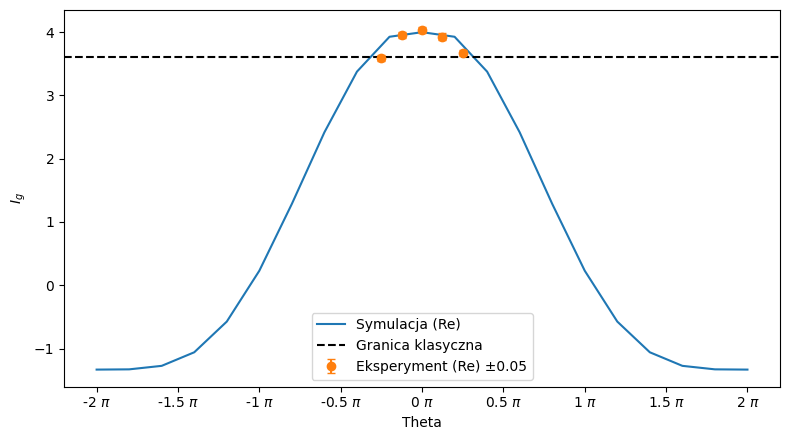

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


experiment = [
    3.59005083550122+0.029654702599154585j,
    3.952735278687443-0.03957411729246172j,
    4.029978242545959-0.006568281851398752j,
    3.9316764947184426+0.04272652932654529j,
    3.667302336439765+0.02027277892576288j,
]
exp_err = 0.05

simulation = [[
    np.complex128(-1.3333333333333282+8.118505867571457e-16j),
    np.complex128(-1.3294189716040925+8.604228440844963e-16j),
    np.complex128(-1.2740510336298425+6.869504964868156e-16j),
    np.complex128(-1.059658704761779+8.81239525796218e-16j),
    np.complex128(-0.5742771331797869+6.349087922075114e-16j),
    np.complex128(0.22930405232440848+2.220446049250313e-16j),
    np.complex128(1.286333417990762-4.2847669856627135e-16j),
    np.complex128(2.417697960687094-1.074661193367632e-15j),
    np.complex128(3.376562108632262-1.6219664500383146e-15j),
    np.complex128(3.927508303541015-2.0365653607967715e-15j),
    np.complex128(4-2.0365653607967715e-15j),
    np.complex128(3.9275083035410168-1.9741153156616065e-15j),
    np.complex128(3.3765621086322555-1.8023776915399026e-15j),
    np.complex128(2.4176979606870885-1.190887666258078e-15j),
    np.complex128(1.286333417990757-7.37257477290143e-16j),
    np.complex128(0.229304052324404-3.729655473350135e-17j),
    np.complex128(-0.574277133179792+4.128641872824801e-16j),
    np.complex128(-1.059658704761783+5.48172618408671e-16j),
    np.complex128(-1.274051033629845+6.106226635438361e-16j),
    np.complex128(-1.329418971604091+6.036837696399289e-16j),
    np.complex128(-1.3333333333333255+7.7021722333370235e-16j),
]]


theta_exp = np.linspace(-0.25*np.pi, 0.25*np.pi, len(experiment))  # [-0.25π, 0.25π]
theta_sim = np.linspace(-2*np.pi, 2*np.pi, len(simulation[0]))     # [-2π, 2π]


exp_real = np.real(np.array(experiment))
sim_real = np.real(np.array(simulation[0]))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(theta_sim/np.pi, sim_real, label="Simulation")
ax.errorbar(theta_exp/np.pi, exp_real, yerr=exp_err, fmt='o', capsize=3,
            label="Experiment ±0.05")

ax.axhline(y=3.61, linestyle="--", color="black", label="Classical bound")

ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
ax.set_xlabel("Theta")
ax.set_ylabel("$I_g$")
ax.legend()
fig.tight_layout()
plt.show()

plt.show()

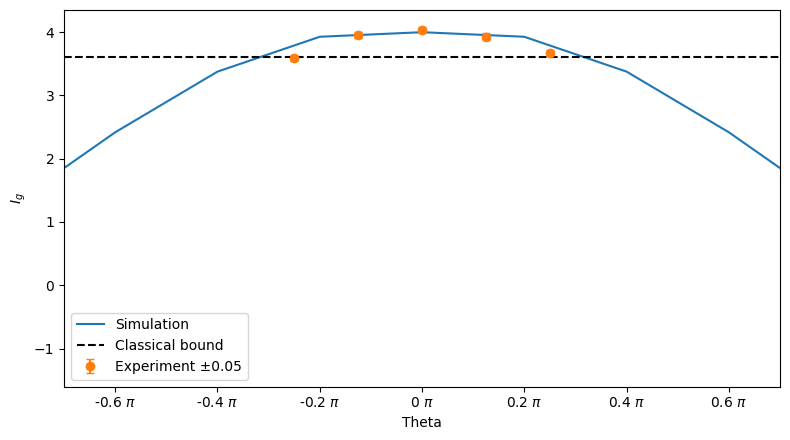

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


experiment = [
    3.59005083550122+0.029654702599154585j,
    3.952735278687443-0.03957411729246172j,
    4.029978242545959-0.006568281851398752j,
    3.9316764947184426+0.04272652932654529j,
    3.667302336439765+0.02027277892576288j,
]
exp_err = 0.05

simulation = [[
    np.complex128(-1.3333333333333282+8.118505867571457e-16j),
    np.complex128(-1.3294189716040925+8.604228440844963e-16j),
    np.complex128(-1.2740510336298425+6.869504964868156e-16j),
    np.complex128(-1.059658704761779+8.81239525796218e-16j),
    np.complex128(-0.5742771331797869+6.349087922075114e-16j),
    np.complex128(0.22930405232440848+2.220446049250313e-16j),
    np.complex128(1.286333417990762-4.2847669856627135e-16j),
    np.complex128(2.417697960687094-1.074661193367632e-15j),
    np.complex128(3.376562108632262-1.6219664500383146e-15j),
    np.complex128(3.927508303541015-2.0365653607967715e-15j),
    np.complex128(4-2.0365653607967715e-15j),
    np.complex128(3.9275083035410168-1.9741153156616065e-15j),
    np.complex128(3.3765621086322555-1.8023776915399026e-15j),
    np.complex128(2.4176979606870885-1.190887666258078e-15j),
    np.complex128(1.286333417990757-7.37257477290143e-16j),
    np.complex128(0.229304052324404-3.729655473350135e-17j),
    np.complex128(-0.574277133179792+4.128641872824801e-16j),
    np.complex128(-1.059658704761783+5.48172618408671e-16j),
    np.complex128(-1.274051033629845+6.106226635438361e-16j),
    np.complex128(-1.329418971604091+6.036837696399289e-16j),
    np.complex128(-1.3333333333333255+7.7021722333370235e-16j),
]]


theta_exp = np.linspace(-0.25*np.pi, 0.25*np.pi, len(experiment))  # [-0.25π, 0.25π]
theta_sim = np.linspace(-2*np.pi, 2*np.pi, len(simulation[0]))     # [-2π, 2π]


exp_real = np.real(np.array(experiment))
sim_real = np.real(np.array(simulation[0]))


fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(theta_sim/np.pi, sim_real, label="Simulation")
ax.errorbar(theta_exp/np.pi, exp_real, yerr=exp_err, fmt='o', capsize=3,
            label="Experiment ±0.05")

ax.axhline(y=3.61, linestyle="--", color="black", label="Classical bound")

ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
ax.set_xlabel("Theta")
ax.set_ylabel("$I_g$")
ax.legend()
fig.tight_layout()
plt.xlim(-0.7, 0.7)
plt.show()

plt.show()

In [40]:
service = QiskitRuntimeService()
job = service.job("d3lv5f83qtks738cqbv0")
print(job.status())


qiskit_runtime_service._resolve_cloud_instances:WARNING:2025-10-30 14:54:27,082: Default instance not set. Searching all available instances.


DONE


In [48]:
job.result()[0].data.evs_noise_factors

array([[ 0.5970806 ,  0.57812312,  0.38105652],
       [ 0.66412005,  0.5723755 ,  0.47070006],
       [ 0.01378521,  0.01769542, -0.13489461],
       [ 0.08647203,  0.0281643 , -0.04759885]])

In [54]:
job.result()[0].data.evs_extrapolated

array([[[        nan,         nan,         nan,         nan],
        [ 0.67637569,  0.62571759,  0.52440139,  0.42308518]],

       [[        nan,         nan,         nan,         nan],
        [ 0.64094009,  0.59981685,  0.51757036,  0.43532387]],

       [[        nan,         nan,         nan,         nan],
        [ 0.12157669,  0.06847858, -0.03771763, -0.14391384]],

       [[        nan,         nan,         nan,         nan],
        [ 0.09303569,  0.07459316,  0.0377081 ,  0.00082304]]])

In [55]:
job.result().metadata

{'dynamical_decoupling': {'enable': False,
  'sequence_type': 'XX',
  'extra_slack_distribution': 'middle',
  'scheduling_method': 'alap'},
 'twirling': {'enable_gates': True,
  'enable_measure': True,
  'num_randomizations': 'auto',
  'shots_per_randomization': 'auto',
  'interleave_randomizations': True,
  'strategy': 'active-accum'},
 'resilience': {'measure_mitigation': True,
  'zne_mitigation': True,
  'pec_mitigation': False,
  'zne': {'noise_factors': [1.0, 3.0, 5.0],
   'extrapolator': ['exponential', 'linear'],
   'extrapolated_noise_factors': [0, 1.0, 3.0, 5.0]}},
 'version': 2}

In [56]:
job = service.job("d3oqmutq5lhs73bb0vp0")
print(job.status())

DONE


In [59]:
job.result()[0].metadata

{'shots': 448,
 'target_precision': 0.05,
 'circuit_metadata': {},
 'resilience': {'zne': {'extrapolator': array(['multiple', 'multiple', 'multiple', 'multiple'], dtype='<U8')}},
 'num_randomizations': 7}

In [58]:
for i in range(101, 107):
    print(f"Qubit {i} properties: {job.properties().qubit_property(i)}")

Qubit 101 properties: {'T1': (0.0002879846347691038, datetime.datetime(2025, 10, 16, 7, 49, 27, tzinfo=tzlocal())), 'T2': (0.00013227734902006945, datetime.datetime(2025, 10, 16, 7, 49, 30, tzinfo=tzlocal())), 'readout_error': (0.0052490234375, datetime.datetime(2025, 10, 16, 21, 44, 46, tzinfo=tzlocal())), 'prob_meas0_prep1': (0.01025390625, datetime.datetime(2025, 10, 16, 9, 35, 34, tzinfo=tzlocal())), 'prob_meas1_prep0': (0.00341796875, datetime.datetime(2025, 10, 16, 9, 35, 40, tzinfo=tzlocal())), 'readout_length': (2.28e-06, datetime.datetime(2025, 10, 16, 21, 44, 46, tzinfo=tzlocal()))}
Qubit 102 properties: {'T1': (0.00029176540315804355, datetime.datetime(2025, 10, 16, 7, 49, 27, tzinfo=tzlocal())), 'T2': (0.00019409179072848374, datetime.datetime(2025, 10, 16, 7, 49, 33, tzinfo=tzlocal())), 'readout_error': (0.00830078125, datetime.datetime(2025, 10, 16, 21, 44, 46, tzinfo=tzlocal())), 'prob_meas0_prep1': (0.03271484375, datetime.datetime(2025, 10, 16, 9, 35, 34, tzinfo=tzloca